In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import networkx as nx
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

%matplotlib inline

# Consistent visual style for the whole notebook
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": "#444444", "axes.labelcolor": "#222222",
    "text.color": "#222222", "xtick.color": "#222222", "ytick.color": "#222222",
    "font.size": 11, "axes.titlesize": 14, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#e0e0e0", "grid.linewidth": 0.6,
})
TEAL, CORAL, NAVY, GOLD, GREY = "#1f7a72", "#e2725b", "#2c3e5c", "#d4a017", "#888888"


In [44]:
df = pd.read_csv("Groceries_dataset.txt")
df.to_csv("Groceries_dataset.csv", index=False)
print(f"Shape: {df.shape}")
df.head()
df.info()

Shape: (38765, 3)
<class 'pandas.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Member_number    38765 non-null  int64
 1   Date             38765 non-null  str  
 2   itemDescription  38765 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.6 MB


In [45]:
print("Unique customers:", df['Member_number'].nunique())
print("Unique products:", df['itemDescription'].nunique())
print("Total purchase records:", len(df))

Unique customers: 3898
Unique products: 167
Total purchase records: 38765


## Data Cleaning

In [46]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nExact duplicate rows: {df.duplicated().sum()}")

Missing values per column:
Member_number      0
Date               0
itemDescription    0
dtype: int64

Exact duplicate rows: 759


In [47]:
# Parse dates and drop exact duplicate records
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")
df = df.drop_duplicates().reset_index(drop=True)

# Reconstruct transactions: same customer + same date = one shopping trip
df["TransactionID"] = df["Member_number"].astype(str) + "_" + df["Date"].dt.strftime("%Y-%m-%d")

print(f"Cleaned shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Number of reconstructed transactions: {df['TransactionID'].nunique():,}")

Cleaned shape: (38006, 4)
Date range: 2014-01-01 to 2015-12-30
Number of reconstructed transactions: 14,963


## EDA

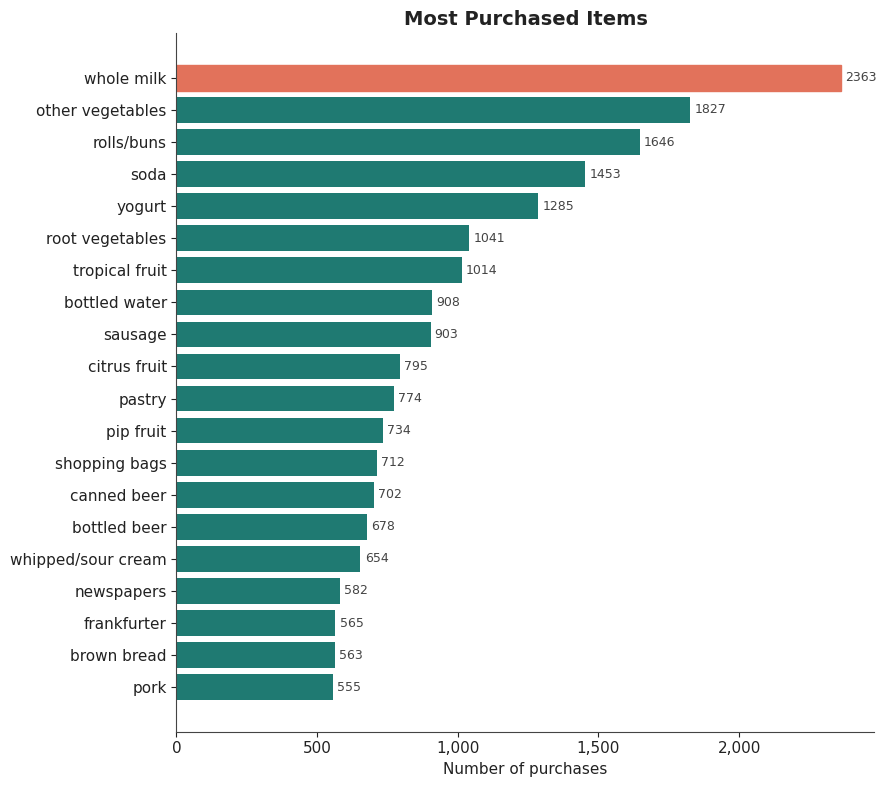

In [48]:
#Most Popular Products

top20 = df["itemDescription"].value_counts().head(20).sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
bars = ax.barh(top20.index, top20.values, color=TEAL)
bars[-1].set_color(CORAL)
ax.set_xlabel("Number of purchases")
ax.set_title("Most Purchased Items")
for i, v in enumerate(top20.values):
    ax.text(v + 15, i, str(v), va="center", fontsize=9, color="#444444")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

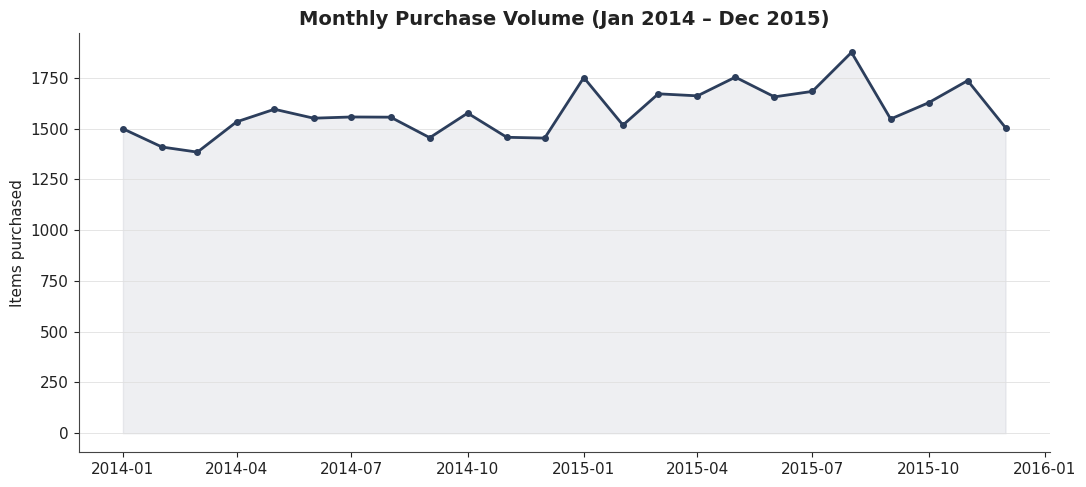

In [49]:
#Purchase Volume Over Time

monthly = df.set_index("Date").resample("MS").size()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly.index, monthly.values, color=NAVY, linewidth=2, marker="o", markersize=4)
ax.fill_between(monthly.index, monthly.values, color=NAVY, alpha=0.08)
ax.set_title("Monthly Purchase Volume (Jan 2014 – Dec 2015)")
ax.set_ylabel("Items purchased")
ax.grid(axis="y")
plt.tight_layout()
plt.show()

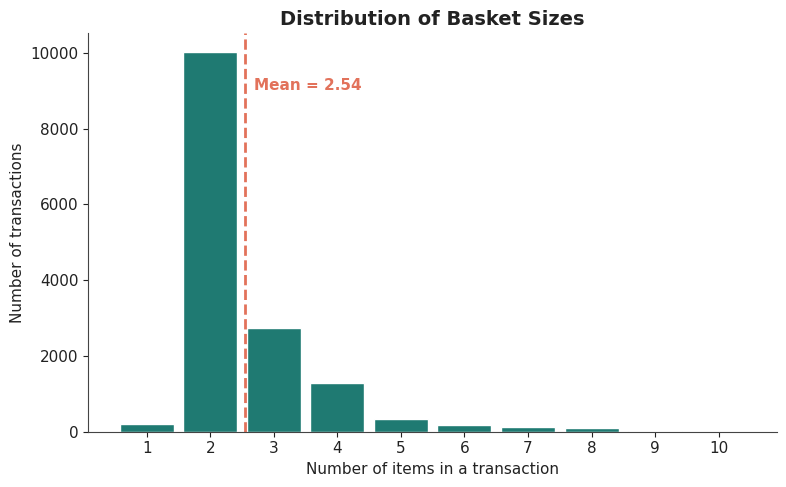

count    14963.000000
mean         2.539999
std          1.060993
min          1.000000
25%          2.000000
50%          2.000000
75%          3.000000
max         10.000000
dtype: float64

In [50]:
#Basket Size Distribution

basket_sizes = df.groupby("TransactionID").size()

fig, ax = plt.subplots(figsize=(8, 5))
counts, bins, patches = ax.hist(basket_sizes, bins=range(1, basket_sizes.max() + 2),
                                  color=TEAL, edgecolor="white", align="left", rwidth=0.85)
ax.set_title("Distribution of Basket Sizes")
ax.set_xlabel("Number of items in a transaction")
ax.set_ylabel("Number of transactions")
ax.set_xticks(range(1, basket_sizes.max() + 1))
mean_val = basket_sizes.mean()
ax.axvline(mean_val, color=CORAL, linestyle="--", linewidth=2)
ax.text(mean_val + 0.15, max(counts) * 0.9, f"Mean = {mean_val:.2f}", color=CORAL, fontweight="bold")
plt.tight_layout()
plt.show()

basket_sizes.describe()

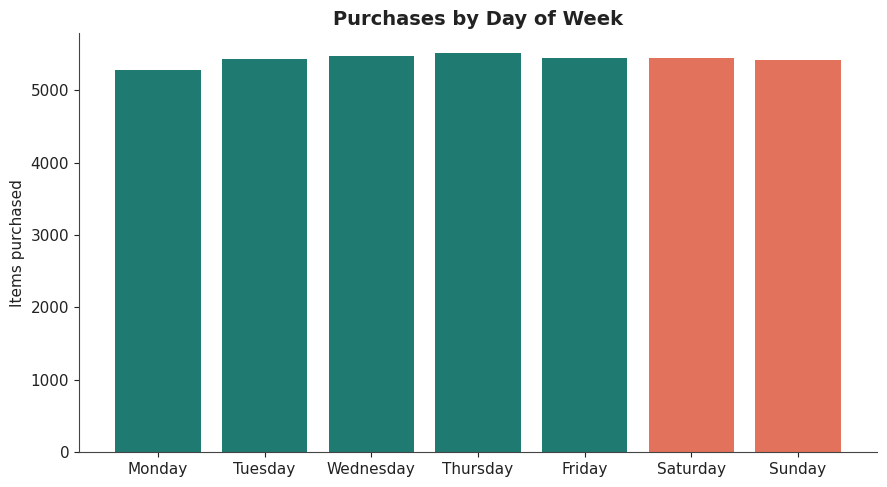

In [51]:
#Purchases by Day of Week

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow = df["Date"].dt.day_name().value_counts().reindex(dow_order)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [CORAL if d in ("Saturday", "Sunday") else TEAL for d in dow_order]
ax.bar(dow.index, dow.values, color=colors)
ax.set_title("Purchases by Day of Week")
ax.set_ylabel("Items purchased")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Apriori Algorithm

In [52]:
#Transaction encoding

transactions = df.groupby("TransactionID")["itemDescription"].apply(list).tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
basket_df = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Encoded basket matrix: {basket_df.shape[0]:,} transactions x {basket_df.shape[1]} products")
basket_df.head()

Encoded basket matrix: 14,963 transactions x 167 products


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [53]:
#Mining frequent items

frequent_itemsets = apriori(basket_df, min_support=0.001, use_colnames=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].apply(len)
frequent_itemsets = frequent_itemsets.sort_values("support", ascending=False)

print(f"Frequent itemsets found: {len(frequent_itemsets)}")
frequent_itemsets.head(10)

Frequent itemsets found: 750


,support,itemsets,length
146,0.157923,frozenset({whole milk}),1
90,0.122101,frozenset({other vegetables}),1
109,0.110005,frozenset({rolls/buns}),1
123,0.097106,frozenset({soda}),1
147,0.085879,frozenset({yogurt}),1
110,0.069572,frozenset({root vegetables}),1
139,0.067767,frozenset({tropical fruit}),1
10,0.060683,frozenset({bottled water}),1
115,0.060349,frozenset({sausage}),1
28,0.053131,frozenset({citrus fruit}),1


In [54]:
#Generating Association rules

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0,
                            num_itemsets=len(frequent_itemsets))
rules["antecedents_str"] = rules["antecedents"].apply(lambda x: ", ".join(sorted(x)))
rules["consequents_str"] = rules["consequents"].apply(lambda x: ", ".join(sorted(x)))
rules = rules.sort_values("lift", ascending=False).reset_index(drop=True)

print(f"Association rules generated: {len(rules)}")
rules[["antecedents_str", "consequents_str", "support", "confidence", "lift"]].head(15)

Association rules generated: 240


,antecedents_str,consequents_str,support,confidence,lift
0,"whole milk, yogurt",sausage,0.001470,0.131737,2.182917
1,sausage,"whole milk, yogurt",0.001470,0.024363,2.182917
2,yogurt,"sausage, whole milk",0.001470,0.017121,1.911760
3,"sausage, whole milk",yogurt,0.001470,0.164179,1.911760
4,citrus fruit,specialty chocolate,0.001403,0.026415,1.653762
5,specialty chocolate,citrus fruit,0.001403,0.087866,1.653762
6,"sausage, yogurt",whole milk,0.001470,0.255814,1.619866
7,whole milk,"sausage, yogurt",0.001470,0.009310,1.619866
8,tropical fruit,flour,0.001069,0.015779,1.617141
9,flour,tropical fruit,0.001069,0.109589,1.617141


## Association

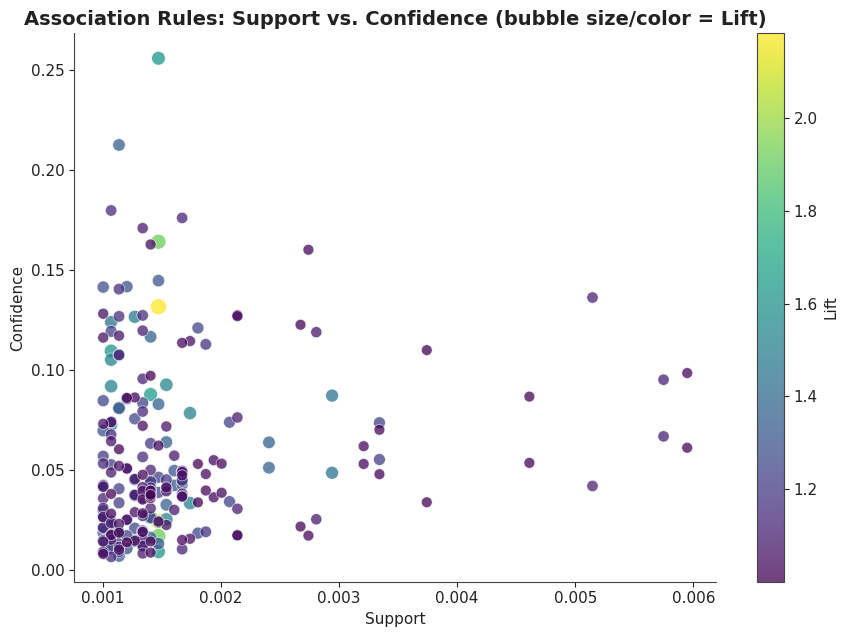

In [55]:
#Support vs. Confidence (sized by Lift)

fig, ax = plt.subplots(figsize=(9, 6.5))
sc = ax.scatter(rules["support"], rules["confidence"],
                 s=rules["lift"] * 60, c=rules["lift"], cmap="viridis",
                 alpha=0.75, edgecolors="white", linewidth=0.5)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Lift")
ax.set_xlabel("Support")
ax.set_ylabel("Confidence")
ax.set_title("Association Rules: Support vs. Confidence (bubble size/color = Lift)")
plt.tight_layout()
plt.show()#

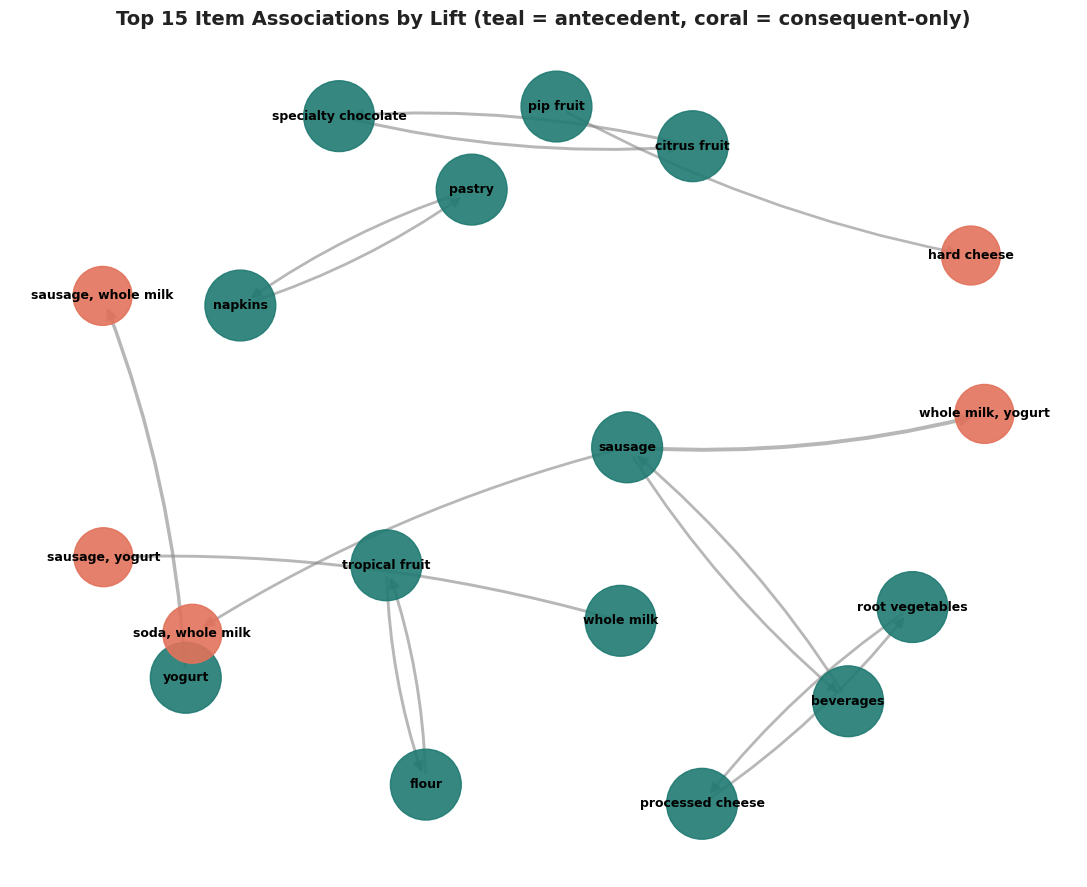

In [56]:
#Network Graph of Top A ssociations

top_rules = rules[rules["antecedents"].apply(len) == 1].drop_duplicates(
    subset=["antecedents_str", "consequents_str"]
).nlargest(15, "lift")

G = nx.DiGraph()
for _, row in top_rules.iterrows():
    G.add_edge(row["antecedents_str"], row["consequents_str"], weight=row["lift"])

fig, ax = plt.subplots(figsize=(11, 9))
pos = nx.spring_layout(G, k=1.4, seed=42)
node_sizes = [2600 if G.out_degree(n) > 0 else 1800 for n in G.nodes()]
node_colors = [TEAL if G.out_degree(n) > 0 else CORAL for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9, ax=ax)
weights = [G[u][v]["weight"] for u, v in G.edges()]
nx.draw_networkx_edges(G, pos, width=[w * 1.3 for w in weights], edge_color=GREY,
                        alpha=0.6, arrowsize=15, ax=ax, connectionstyle="arc3,rad=0.08")
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold", ax=ax)
ax.set_title("Top 15 Item Associations by Lift (teal = antecedent, coral = consequent-only)")
ax.axis("off")
plt.tight_layout()
plt.show()

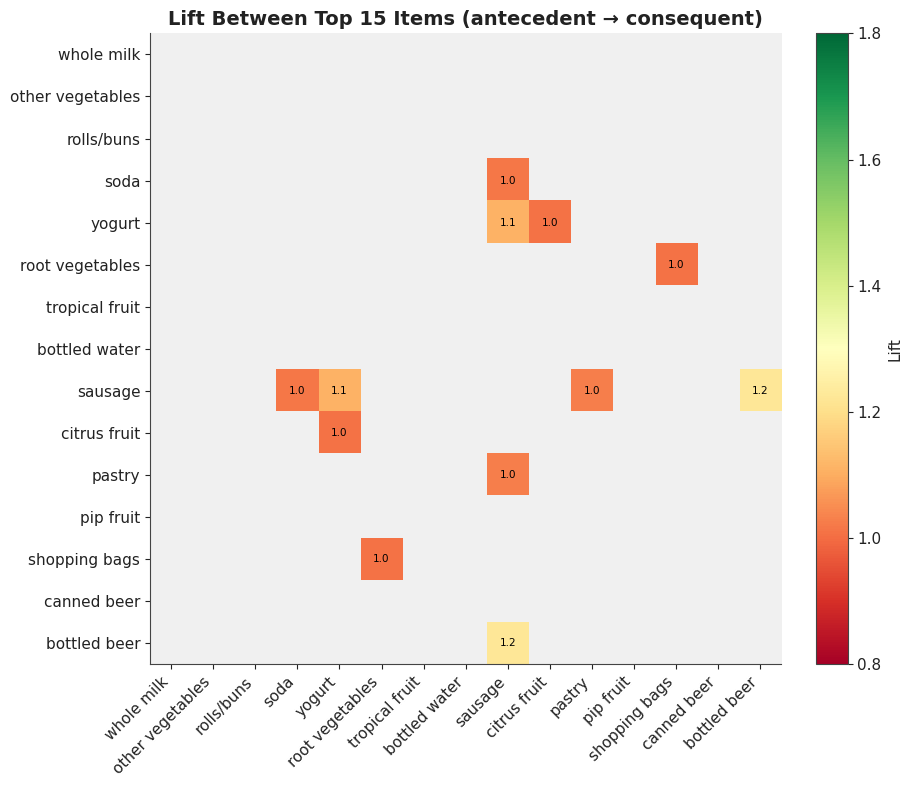

In [57]:
#Lift heatmap (top 15 products)

top_items = df["itemDescription"].value_counts().head(15).index.tolist()
pairs = rules[rules["antecedents_str"].isin(top_items) & rules["consequents_str"].isin(top_items)]

lift_matrix = pd.DataFrame(np.nan, index=top_items, columns=top_items)
for _, row in pairs.iterrows():
    lift_matrix.loc[row["antecedents_str"], row["consequents_str"]] = row["lift"]

fig, ax = plt.subplots(figsize=(10, 8))
cmap = plt.cm.RdYlGn.copy()
cmap.set_bad("#f0f0f0")
masked = np.ma.masked_invalid(lift_matrix.values)
im = ax.imshow(masked, cmap=cmap, vmin=0.8, vmax=1.8)
ax.set_xticks(range(len(top_items))); ax.set_yticks(range(len(top_items)))
ax.set_xticklabels(top_items, rotation=45, ha="right")
ax.set_yticklabels(top_items)
ax.set_title("Lift Between Top 15 Items (antecedent → consequent)")
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Lift")
for i in range(len(top_items)):
    for j in range(len(top_items)):
        val = lift_matrix.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=7.5, color="black")
plt.tight_layout()
plt.show()

## Key Insights & Business Recommendation

# Findings
1. **Sausage, yogurt, and whole milk form the strongest cluster.** Customers who buy whole milk + yogurt are over **2x as likely** to also buy sausage (lift 2.18) compared to chance — and the reverse direction holds too.
2. **Citrus fruit ↔ specialty chocolate** is a notable cross-category pairing (lift 1.65), suggesting a "treat" purchase pattern.
3. **Tropical fruit ↔ flour** (lift 1.62) hints at home-baking behavior (e.g. fruit-based baked goods).
4. **Best-selling items are not the most "associated" items.** Staples like whole milk and vegetables show lift ≈ 1 with nearly everything — they're bought out of routine, not because of what else is in the basket.
5. **No strong weekly seasonality** — shopping behavior is steady across days and months, simplifying inventory planning.

# Business Recommendations
1. **Cross-merchandising:** place sausage near the dairy aisle (milk/yogurt), and tropical fruit near baking supplies — physical proximity nudges the already-observed pairing into more frequent co-purchase.
2. **Bundle promotions:** "Breakfast bundle" (milk + yogurt + sausage) or "Baking bundle" (flour + tropical fruit) discount offers, targeting customers who already show this latent preference.
3. **Recommendation engine seed rules:** the mined rules can directly seed a "customers who bought this also bought…" feature on an online ordering platform.
4. **Don't over-promote staples together** — bundling milk with vegetables adds little incremental lift since customers buy both anyway.
